In [1]:
import scanpy as sc
import anndata as ad
from matplotlib.gridspec import GridSpec
import matplotlib.pyplot as plt
from matplotlib_scalebar.scalebar import ScaleBar
from matplotlib.colors import ListedColormap, rgb2hex
import numpy as np
import warnings
import pandas as pd
warnings.filterwarnings('ignore')
from sklearn.metrics import jaccard_score
import seaborn as sns
import matplotlib.pyplot as plt
plt.rcParams['pdf.fonttype'] = 42 

from matplotlib.font_manager import fontManager, FontProperties

fontManager.addfont('/data/work/Arial.ttf')

font = FontProperties(fname='/data/work/Arial.ttf')
font_name = font.get_name()
plt.rcParams['font.family'] = font_name

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
def corr_plot(corr_matrix, save_name, figsize):


    g = sns.clustermap(
        corr_matrix,
        annot=False,
        cmap='coolwarm',
        square=True,
        linewidths=.5,
        cbar_pos=None,          
        dendrogram_ratio=0.15,  
        figsize=figsize,
        row_cluster=True,
        col_cluster=True,
        yticklabels=True,
        xticklabels = True,
        tree_kws={'linewidths': 1.0}
    )

    g.ax_heatmap.yaxis.tick_left()
    g.ax_heatmap.yaxis.set_label_position('left')

    heatmap_pos = g.ax_heatmap.get_position()
    row_dend_pos = g.ax_row_dendrogram.get_position()

    g.ax_row_dendrogram.set_position([heatmap_pos.x1,
                                      row_dend_pos.y0, 
                                     row_dend_pos.width, row_dend_pos.height])

    g.ax_row_dendrogram.invert_xaxis()

    cbar_ax = g.fig.add_axes([heatmap_pos.x1 + 0.2, 0.5, 0.03, 0.2])  
    cbar_ax.set_title('Correlation', fontsize=12, pad=10)
    g.fig.colorbar(g.ax_heatmap.collections[0], cax=cbar_ax)

    g.ax_heatmap.set_xlabel('Mouse Brain celltype', fontsize=14, fontweight='bold')
    g.ax_heatmap.set_ylabel('Lamprey Brain celltype', fontsize=14, fontweight='bold')

    plt.setp(g.ax_heatmap.get_xticklabels(), rotation=45, ha='right')
    plt.setp(g.ax_heatmap.get_yticklabels(), rotation=0)

    plt.savefig(save_name, bbox_inches = 'tight')
    plt.close()

In [3]:
import plotly.graph_objects as go
import numpy as np

def plot_sankey_from_corr(corr_matrix, threshold=0.3, output_path=None):

    lamprey_labels = list(corr_matrix.index)
    mouse_labels = list(corr_matrix.columns)
    all_labels = lamprey_labels + mouse_labels
    
    label_to_idx = {label: idx for idx, label in enumerate(all_labels)}
    
    sources = []
    targets = []
    values = []
    colors = []
    
    for i, lamprey_type in enumerate(lamprey_labels):
        for j, mouse_type in enumerate(mouse_labels):
            corr_val = corr_matrix.loc[lamprey_type, mouse_type]
            
            if corr_val > threshold:
                sources.append(label_to_idx[lamprey_type])
                targets.append(label_to_idx[mouse_type])
                values.append(corr_val)
                
                alpha = min(corr_val, 1.0)
                colors.append(f'rgba(31, 119, 180, {alpha})')
    
    node_colors = ['rgba(255, 127, 14, 0.8)'] * len(lamprey_labels) + \
                  ['rgba(44, 160, 44, 0.8)'] * len(mouse_labels)
    
    fig = go.Figure(data=[go.Sankey(
        node=dict(
            pad=15,
            thickness=20,
            line=dict(color="black", width=0.5),
            label=all_labels,
            color=node_colors
        ),
        link=dict(
            source=sources,
            target=targets,
            value=values,
            color=colors
        )
    )])
    
    fig.update_layout(
        title_text="Lamprey-Mouse Cell Type Correlation Sankey",
        font_size=10,
        height=1200,
        width=1000
    )
    
    if output_path:
        if output_path.endswith('.html'):
            fig.write_html(output_path)
        else:
            fig.write_image(output_path)
    
    fig.show()
    return fig




In [4]:
adata = sc.read_h5ad('/data/work/22.fusemap/05.stereoalign/02.scvi/04.Striatum/scvi_corrected.h5ad')
adata

AnnData object with n_obs × n_vars = 10768 × 6292
    obs: 'region', 'slices', 'ax', 'ay', 'az', 'celltype', 'species', 'n_counts', 'log_counts', 'n_genes'
    var: 'n_cells', 'mean-0', 'std-0', 'mean-1', 'std-1'
    obsm: 'aligned_scvi'
    layers: 'counts'

In [5]:
lamprey_pro = pd.read_csv('/data/work/22.fusemap/05.stereoalign/lamprey_color_spatial.csv', index_col = 'Unnamed: 0')
lamprey_pro_dict = dict(zip(lamprey_pro['spatialCluster'], lamprey_pro['spatialClusterV2']))

In [6]:
dic = {
    '1': 'mouse',
    '0': 'lamprey',
}
adata.obs['species'] = [dic[i] for i in adata.obs['species']]

In [7]:
csv=pd.read_csv('/data/users/wuhaixu/online/240726_newScviMerge/metadata/lamprey.Str.anno_whole_cluster.csv', index_col = 'Unnamed: 0')
inte = list(set(csv.index.tolist()) & set(adata[adata.obs['species'] == 'lamprey'].obs.index.tolist()))
csv = csv.loc[inte].copy()
lamprey_adata = adata[inte].copy()
mouse_adata = adata[adata.obs['species']=='mouse'].copy()
lamprey_adata.obs['celltype'] = csv['anno_whole_cluster'].tolist()
adata = ad.concat([mouse_adata, lamprey_adata])

In [8]:
adata.obs['celltype'] = adata.obs['species'].astype(str) +'_'+ adata.obs['celltype'].astype(str)

In [9]:
df = pd.DataFrame(adata.obs['celltype'].value_counts())
df = df[df['celltype']>100]
temp = adata[adata.obs['celltype'].isin(df.index.tolist())]
temp

View of AnnData object with n_obs × n_vars = 9378 × 6292
    obs: 'region', 'slices', 'ax', 'ay', 'az', 'celltype', 'species', 'n_counts', 'log_counts', 'n_genes'
    obsm: 'aligned_scvi'
    layers: 'counts'

In [10]:
set(temp.obs['celltype'])

{'lamprey_Str-Glia-1',
 'lamprey_Str-Neu-1',
 'lamprey_Str-Neu-2',
 'lamprey_Str-Neu-3',
 'lamprey_Str-Neu-4',
 'lamprey_Str-Neu-5',
 'lamprey_Str-Neu-6',
 'lamprey_Str-Neu-7',
 'mouse_Microglia',
 'mouse_Olfactory bulb inhibitory neurons',
 'mouse_Oligodendrocytes',
 'mouse_Telencephalon excitatory neurons',
 'mouse_Telencephalon inhibitory neurons',
 'mouse_Vascular and leptomeningeal cells'}

In [11]:
raw_indexs = [
 'lamprey_Str-Glia-1',
 'lamprey_Str-Neu-1',
 'lamprey_Str-Neu-2',
 'lamprey_Str-Neu-3',
 'lamprey_Str-Neu-4',
 'lamprey_Str-Neu-5',
 'lamprey_Str-Neu-6',
 'lamprey_Str-Neu-7',
]
raw_columns = ['mouse_Microglia',
 'mouse_Olfactory bulb inhibitory neurons',
 'mouse_Oligodendrocytes',
 'mouse_Telencephalon excitatory neurons',
 'mouse_Telencephalon inhibitory neurons',
 'mouse_Vascular and leptomeningeal cells']
scvi_repr = temp.obsm['aligned_scvi']
cell_types = temp.obs['celltype'].values
df = pd.DataFrame(scvi_repr, index=temp.obs.index)
df['cell_type'] = cell_types
mean_repr = df.groupby('cell_type').mean()
corr_matrix = mean_repr.T.corr('pearson')
corr_matrix = corr_matrix[raw_columns].loc[raw_indexs]
corr_matrix.index = [i.replace('lamprey_', '') for i in corr_matrix.index]
corr_matrix.index = [lamprey_pro_dict[i] if i in lamprey_pro_dict else i for i in corr_matrix.index ]
corr_matrix.columns = [i.replace('mouse_', ' ') for i in corr_matrix.columns]
corr_plot(corr_matrix, '/data/work/22.fusemap/05.stereoalign/02.scvi/04.Striatum/01_20251223/Striatum_1.pdf', (3,4))

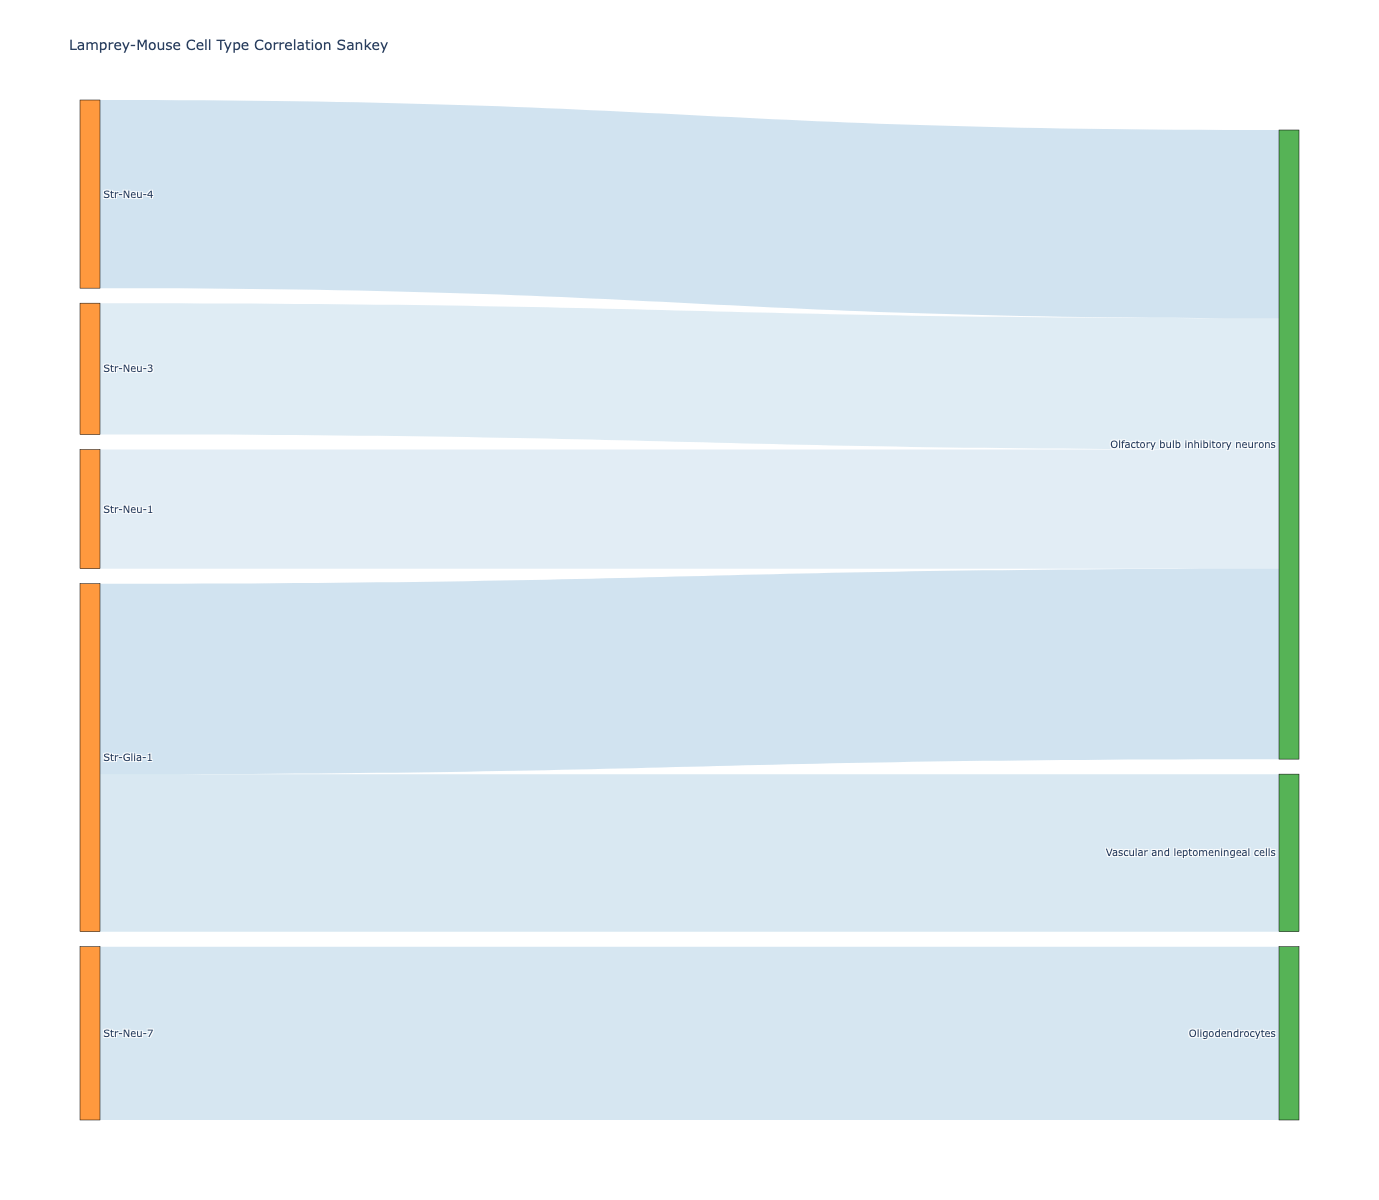

In [12]:
fig = plot_sankey_from_corr(corr_matrix, threshold=0.1, )
fig.write_html('/data/work/22.fusemap/05.stereoalign/02.scvi/04.Striatum/01_20251223/Striatum_1.html')

In [13]:
mouse = sc.read_h5ad('/data/work/22.fusemap/01.datas/04.Striatum/mouse_brain_stereo_3d.h5ad')

In [14]:
lamprey_celltype = adata[adata.obs['species'] == 'lamprey'].obs['celltype'].tolist()
mouse_celltype = 'mouse_' + mouse.obs['cell_cluster'].astype(str)
mouse_celltype = mouse_celltype.tolist()

In [15]:
new_celltype =  mouse_celltype+ lamprey_celltype

In [16]:
adata[adata.obs['species'] == 'lamprey']

View of AnnData object with n_obs × n_vars = 4154 × 6292
    obs: 'region', 'slices', 'ax', 'ay', 'az', 'celltype', 'species', 'n_counts', 'log_counts', 'n_genes'
    obsm: 'aligned_scvi'
    layers: 'counts'

In [17]:
adata.obs['new_celltype'] = new_celltype

In [18]:
df = pd.DataFrame(adata.obs['new_celltype'].value_counts())
df = df[df['new_celltype']>100]
temp = adata[adata.obs['new_celltype'].isin(df.index.tolist())]
temp

View of AnnData object with n_obs × n_vars = 7232 × 6292
    obs: 'region', 'slices', 'ax', 'ay', 'az', 'celltype', 'species', 'n_counts', 'log_counts', 'n_genes', 'new_celltype'
    obsm: 'aligned_scvi'
    layers: 'counts'

In [19]:
set(temp.obs['new_celltype'])

{'lamprey_Str-Glia-1',
 'lamprey_Str-Neu-1',
 'lamprey_Str-Neu-2',
 'lamprey_Str-Neu-3',
 'lamprey_Str-Neu-4',
 'lamprey_Str-Neu-5',
 'lamprey_Str-Neu-6',
 'lamprey_Str-Neu-7',
 'mouse_L6_Car3_GLU_55',
 'mouse_L6_Car3_GLU_56',
 'mouse_L6_Car3_GLU_57',
 'mouse_L6_IT_GLU_52',
 'mouse_L6_N_GLU_63',
 'mouse_L6_N_GLU_64',
 'mouse_MGL_290',
 'mouse_OB_N_GABA_163',
 'mouse_TE_N_GABA_RELN_107',
 'mouse_TE_N_GABA_SST_128',
 'mouse_TE_N_GLU_1',
 'mouse_TE_N_GLU_10',
 'mouse_TE_N_GLU_2',
 'mouse_TE_N_GLU_27',
 'mouse_TE_N_GLU_6',
 'mouse_TE_N_GLU_7',
 'mouse_TE_N_GLU_9',
 'mouse_VLMC_270'}

In [20]:
raw_indexs = [
 'lamprey_Str-Glia-1',
 'lamprey_Str-Neu-1',
 'lamprey_Str-Neu-2',
 'lamprey_Str-Neu-3',
 'lamprey_Str-Neu-4',
 'lamprey_Str-Neu-5',
 'lamprey_Str-Neu-6',
 'lamprey_Str-Neu-7',
]
raw_columns = ['mouse_L6_Car3_GLU_55',
 'mouse_L6_Car3_GLU_56',
 'mouse_L6_Car3_GLU_57',
 'mouse_L6_IT_GLU_52',
 'mouse_L6_N_GLU_63',
 'mouse_L6_N_GLU_64',
 'mouse_MGL_290',
 'mouse_OB_N_GABA_163',
 'mouse_TE_N_GABA_RELN_107',
 'mouse_TE_N_GABA_SST_128',
 'mouse_TE_N_GLU_1',
 'mouse_TE_N_GLU_10',
 'mouse_TE_N_GLU_2',
 'mouse_TE_N_GLU_27',
 'mouse_TE_N_GLU_6',
 'mouse_TE_N_GLU_7',
 'mouse_TE_N_GLU_9',
 'mouse_VLMC_270']
scvi_repr = temp.obsm['aligned_scvi']
cell_types = temp.obs['new_celltype'].values
df = pd.DataFrame(scvi_repr, index=temp.obs.index)
df['cell_type'] = cell_types
mean_repr = df.groupby('cell_type').mean()
corr_matrix = mean_repr.T.corr('pearson')
corr_matrix = corr_matrix[raw_columns].loc[raw_indexs]
corr_matrix.index = [i.replace('lamprey_', '') for i in corr_matrix.index]
corr_matrix.index = [lamprey_pro_dict[i] if i in lamprey_pro_dict else i for i in corr_matrix.index ]
corr_matrix.columns = [i.replace('mouse_', ' ') for i in corr_matrix.columns]
corr_plot(corr_matrix, '/data/work/22.fusemap/05.stereoalign/02.scvi/04.Striatum/01_20251223/Striatum_2.pdf', (9,5))

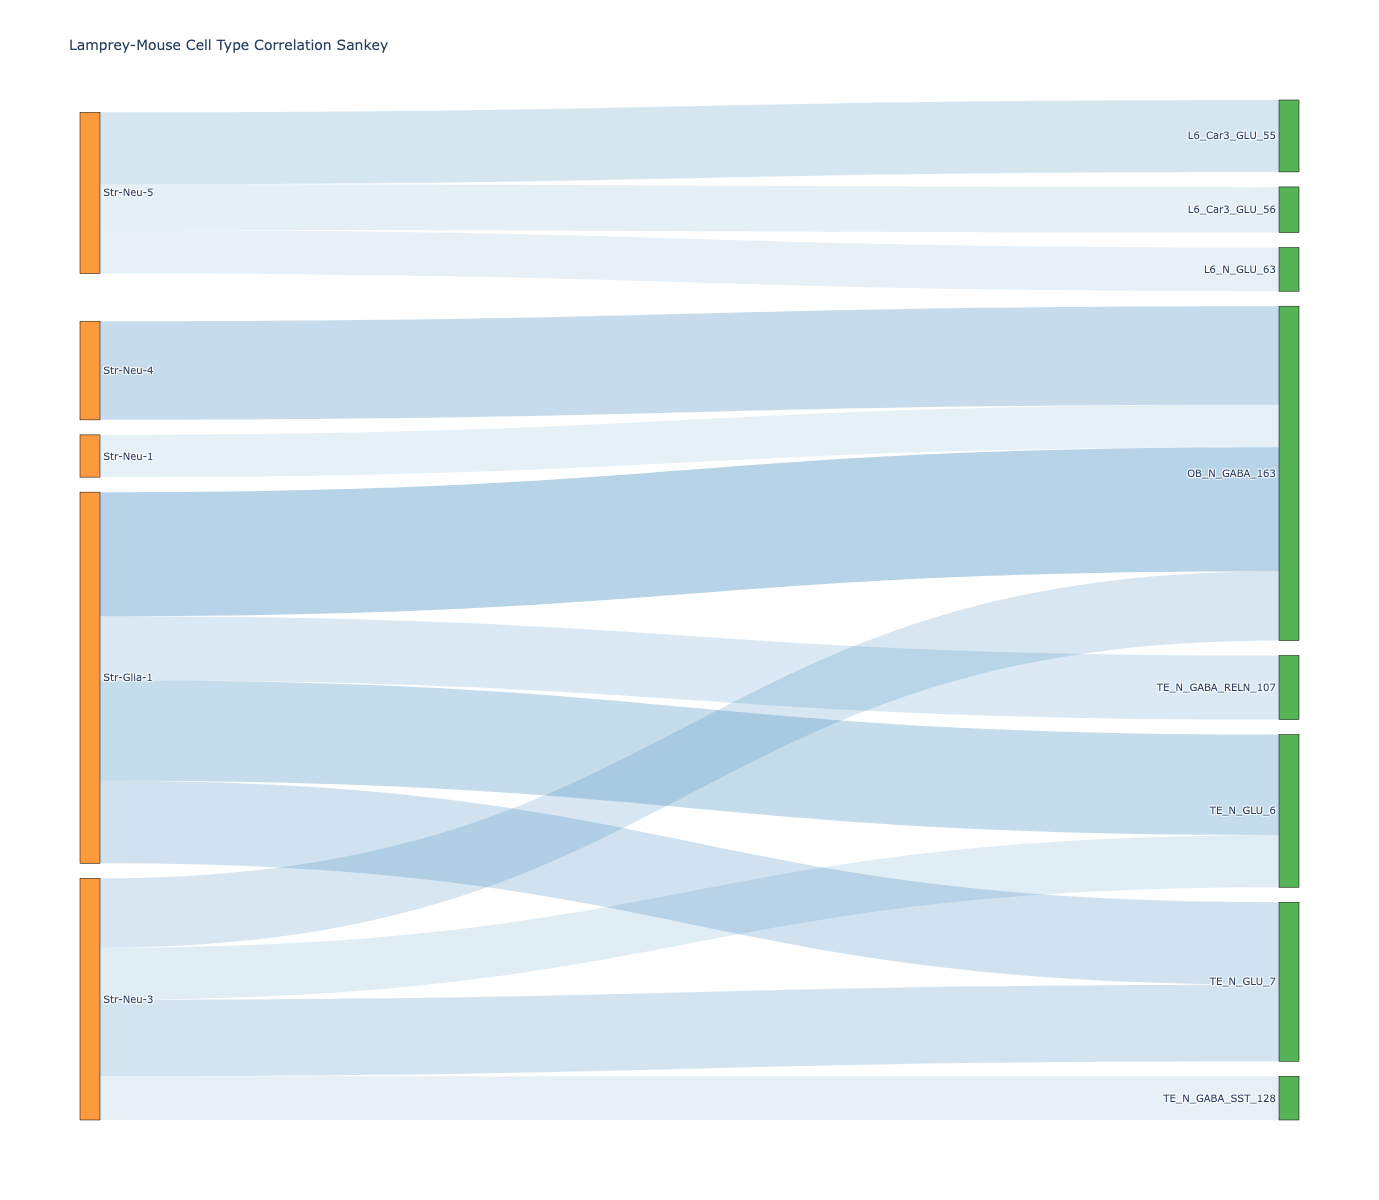

In [21]:
fig = plot_sankey_from_corr(corr_matrix, threshold=0.1, )
fig.write_html('/data/work/22.fusemap/05.stereoalign/02.scvi/04.Striatum/01_20251223/Striatum_2.html')

In [22]:
raw_indexs = [
 'lamprey_Str-Glia-1',
 'lamprey_Str-Neu-1',
 'lamprey_Str-Neu-2',
 'lamprey_Str-Neu-3',
 'lamprey_Str-Neu-4',
 'lamprey_Str-Neu-5',
 'lamprey_Str-Neu-6',
 'lamprey_Str-Neu-7',
]
raw_columns = [
 'mouse_MGL_290',
 'mouse_OB_N_GABA_163',
 'mouse_TE_N_GABA_RELN_107',
 'mouse_TE_N_GABA_SST_128',
 'mouse_TE_N_GLU_1',
 'mouse_TE_N_GLU_10',
 'mouse_TE_N_GLU_2',
 'mouse_TE_N_GLU_27',
 'mouse_TE_N_GLU_6',
 'mouse_TE_N_GLU_7',
 'mouse_TE_N_GLU_9',
 'mouse_VLMC_270']
scvi_repr = temp.obsm['aligned_scvi']
cell_types = temp.obs['new_celltype'].values
df = pd.DataFrame(scvi_repr, index=temp.obs.index)
df['cell_type'] = cell_types
mean_repr = df.groupby('cell_type').mean()
corr_matrix = mean_repr.T.corr('pearson')
corr_matrix = corr_matrix[raw_columns].loc[raw_indexs]
corr_matrix.index = [i.replace('lamprey_', '') for i in corr_matrix.index]
corr_matrix.index = [lamprey_pro_dict[i] if i in lamprey_pro_dict else i for i in corr_matrix.index ]
corr_matrix.columns = [i.replace('mouse_', ' ') for i in corr_matrix.columns]
corr_plot(corr_matrix, '/data/work/22.fusemap/05.stereoalign/02.scvi/04.Striatum/01_20251223/Striatum_3.pdf', (5,5))

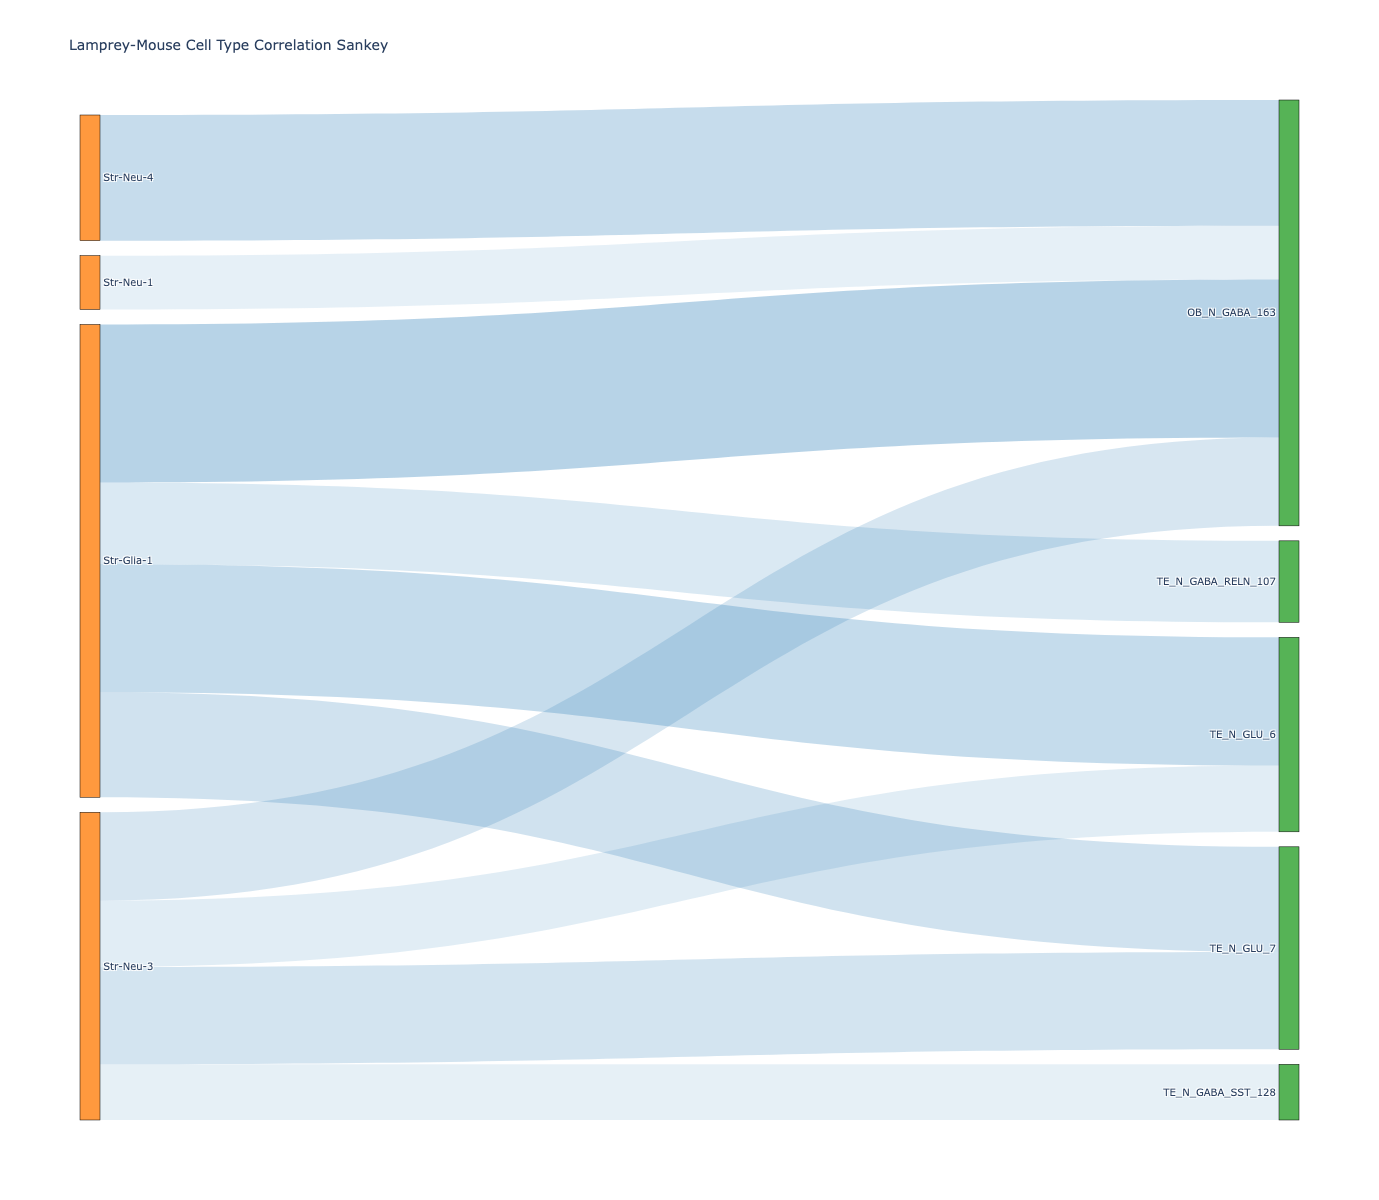

In [23]:
fig = plot_sankey_from_corr(corr_matrix, threshold=0.1, )
fig.write_html('/data/work/22.fusemap/05.stereoalign/02.scvi/04.Striatum/01_20251223/Striatum_3.html')